In [2]:
# ==============================================================================
# PIPELINE DA TURMA
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configuração visual padrão
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [4]:
print(" Carregando a Base de Dados da Turma...")

# 1. GERANDO A BASE DE DADOS MAIOR (10000 Registros de E-commerce)
np.random.seed(42)
n_linhas = 100000
dados = {
    'ID_Pedido': range(1, n_linhas + 1),
    'Idade_Cliente': np.random.randint(18, 70, n_linhas),
    'Categoria': np.random.choice(['Eletrônicos', 'Roupas', 'Casa', 'Games', 'Livros'], n_linhas),
    'Plataforma': np.random.choice(['App', 'Site', 'Instagram'], n_linhas, p=[0.5, 0.3, 0.2]),
    'Quantidade': np.random.randint(1, 6, n_linhas),
    'Valor_Unitario': np.random.uniform(50.0, 1500.0, n_linhas).round(2),
    'Avaliacao_Cliente': np.random.randint(1, 6, n_linhas) # Nota de 1 a 5
}

df = pd.DataFrame(dados)

 Carregando a Base de Dados da Turma...


In [5]:
print("\n --- Amostra dos Dados Originais ---")
display(df.head(10))


 --- Amostra dos Dados Originais ---


,ID_Pedido,Idade_Cliente,Categoria,Plataforma,Quantidade,Valor_Unitario,Avaliacao_Cliente
0,1,56,Games,App,5,1087.21,2
1,2,69,Roupas,Site,1,1167.68,4
2,3,46,Eletrônicos,Site,1,1093.83,3
3,4,32,Livros,Instagram,5,894.40,5
4,5,60,Casa,App,4,463.65,2
5,6,25,Casa,Instagram,1,1419.54,4
6,7,38,Casa,Instagram,4,252.66,5
7,8,56,Roupas,Site,5,326.69,3
8,9,36,Games,Instagram,4,841.99,5
9,10,40,Casa,Site,1,444.51,5


In [6]:
df.describe()

,ID_Pedido,Idade_Cliente,Quantidade,Valor_Unitario,Avaliacao_Cliente
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,43.500270,3.008500,774.783473,3.003310
std,28867.657797,14.970933,1.414697,418.729650,1.412069
min,1.000000,18.000000,1.000000,50.030000,1.000000
25%,25000.750000,31.000000,2.000000,413.060000,2.000000
50%,50000.500000,43.000000,3.000000,775.000000,3.000000
75%,75000.250000,56.000000,4.000000,1137.240000,4.000000
max,100000.000000,69.000000,5.000000,1499.990000,5.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID_Pedido          100000 non-null  int64  
 1   Idade_Cliente      100000 non-null  int32  
 2   Categoria          100000 non-null  str    
 3   Plataforma         100000 non-null  str    
 4   Quantidade         100000 non-null  int32  
 5   Valor_Unitario     100000 non-null  float64
 6   Avaliacao_Cliente  100000 non-null  int32  
dtypes: float64(1), int32(3), int64(1), str(2)
memory usage: 4.2 MB


# ==============================================================================
#  ÁREA DE TRABALHO DOS ALUNOS
# ==============================================================================
# REGRAS:
# 1. Crie UMA nova coluna no DataFrame (Transformação).
# 2. Crie UM gráfico (Visualização) para explicar essa ou outra coluna.
# 3. Coloque um comentário com o seu nome antes do seu código!
# 4. Fique a vontade para fazer qualquer modificação
# ==============================================================================

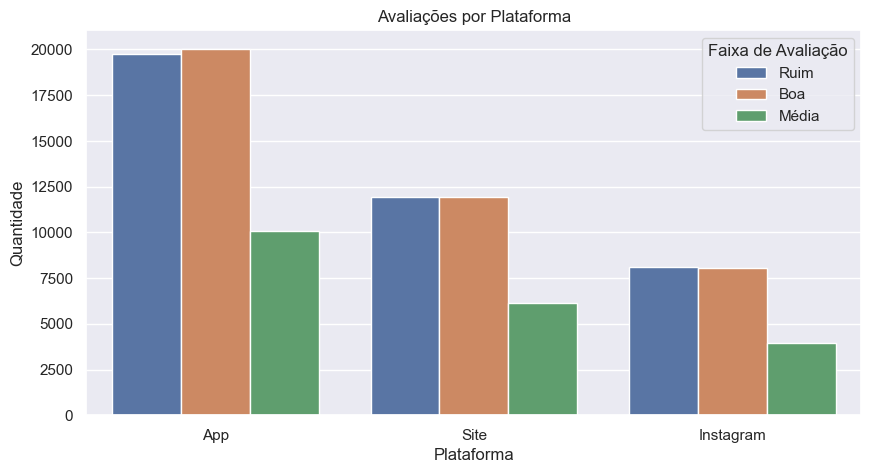


INSIGHT:
 O grafico indica a proporção de avaliações para cada plataforma.



In [8]:
# <<< ADICIONE O SEU CÓDIGO ABAIXO DESTA LINHA DE FORMA ORGANIZADA>>>
# Adicionando coluna faixa de avaliação, dividindo as notas entre Ruim (1-2), Média (3) e Boa (4-5)
condicoes = [
    df['Avaliacao_Cliente'] <= 2,
    df['Avaliacao_Cliente'] == 3,
    df['Avaliacao_Cliente'] >= 4
]

valores = ['Ruim', 'Média', 'Boa']

df['Faixa_Avaliacao'] = np.select(
    condicoes,
    valores,
    default='Não classificado'
)

df[['Avaliacao_Cliente', 'Faixa_Avaliacao']].head()

plt.figure()

sns.countplot(
    data=df,
    x='Plataforma',
    hue='Faixa_Avaliacao'
)

plt.title('Avaliações por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Quantidade')

plt.legend(title='Faixa de Avaliação')

plt.show()

print("""
INSIGHT:
 O grafico indica a proporção de avaliações para cada plataforma.
""")

In [9]:
# --- Exemplo Coluna: Welington ---
# Criando uma coluna de faturamento base para facilitar a vida
# df['Faturamento_Total'] = df['Quantidade'] * df['Valor_Unitario']

In [10]:
# --- Exemplo Gráfico: Welington ---
# df['Status_Venda'] = np.where(df['Faturamento_Total'] > 3000, 'VIP', 'Normal')
# plt.figure()
# sns.countplot(data=df, x='Plataforma', palette='viridis')
# plt.title('Volume de Vendas por Plataforma - Welington')
# plt.show()


 --- Mostrando tabela com a coluna Faixa Etaria Criada ---


,ID_Pedido,Idade_Cliente,Categoria,Plataforma,Quantidade,Valor_Unitario,Avaliacao_Cliente,Faixa_Avaliacao,Faixa_Etaria
0,1,56,Games,App,5,1087.21,2,Ruim,40-60
1,2,69,Roupas,Site,1,1167.68,4,Boa,60+
2,3,46,Eletrônicos,Site,1,1093.83,3,Média,40-60
3,4,32,Livros,Instagram,5,894.40,5,Boa,20-40
4,5,60,Casa,App,4,463.65,2,Ruim,40-60
5,6,25,Casa,Instagram,1,1419.54,4,Boa,20-40
6,7,38,Casa,Instagram,4,252.66,5,Boa,20-40
7,8,56,Roupas,Site,5,326.69,3,Média,40-60
8,9,36,Games,Instagram,4,841.99,5,Boa,20-40
9,10,40,Casa,Site,1,444.51,5,Boa,20-40


Categoria     Casa  Eletrônicos  Games  Livros  Roupas
Faixa_Etaria                                          
0-20          1187         1121   1189    1116    1120
20-40         7703         7699   7602    7750    7804
40-60         7543         7741   7756    7676    7714
60+           3469         3468   3368    3529    3445


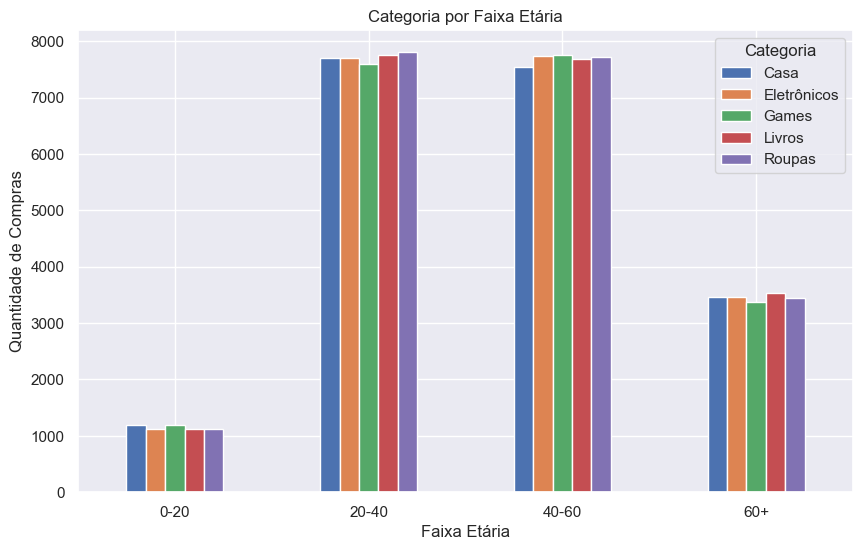

In [ ]:
# --- Exemplo Coluna: FelipeLazarotto ---
# Criando uma coluna de faixa etaria 0-20, 20-40, 40-60 e 60+
df['Faixa_Etaria'] = pd.cut(df['Idade_Cliente'], bins=[0, 20, 40, 60, 100], labels=['0-20', '20-40', '40-60', '60+'])
print("\n --- Mostrando tabela com a coluna Faixa Etaria Criada ---")
display(df.head(10))

# --- Exemplo Gráfico: FelipeLazarotto ---
relacao = pd.crosstab(df['Faixa_Etaria'],df['Categoria'])
print(relacao)
relacao.plot(kind='bar', figsize=(10,6))
plt.title('Categoria por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade de Compras')
plt.xticks(rotation=0)
plt.show()